In [1]:
import os
import math
import pickle
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, cm
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"
atlas_base_path = "../pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx]
cortex = np.where(atlas_only_brain != 0)[0]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)

In [3]:
# participant_data_path = "/home/zachkaras/fmri/fmri_model_data/midprocess/133/filtered_func_data_clean.nii.gz"
# participant_data_path = "/storage1/fmri_model_data/midprocess/133/filtered_func_data_clean.nii.gz"
participant_data_path = "/storage1/fmri_model_data/clean_code/133.nii.gz"

fmri_data = nib.load(participant_data_path)
scan = fmri_data.get_fdata()

In [4]:
# reshape data to 2d
scan_2d = (np.reshape(scan, [scan.shape[0]*scan.shape[1]*scan.shape[2], scan.shape[3]]))

In [5]:
# z-score the data
means = scan_2d.mean(axis=1, keepdims=True)
stds = scan_2d.std(axis=1, keepdims=True)

z_scored_2d_scan = (scan_2d - means) / np.where(stds==0, 1, stds)

In [6]:
# Only looking at voxels in the MNI brain
scan_2d_brain = z_scored_2d_scan[brain_idx, :]

# Only looking at voxels labeled in the Schaefer Atlas
scan_2d_schaefer = scan_2d_brain[cortex,:]
scan_2d_schaefer = scan_2d_schaefer.T

In [7]:
scan_2d_schaefer.shape

(746, 131065)

In [8]:
with open("/storage1/fmri_model_data/vols_to_skip/133_vols_to_skip.pkl", 'rb') as f:
    vols_to_skip = pickle.load(f)

In [9]:
vol_nums = np.ones((scan_2d_schaefer.shape)[0])
vol_nums[vols_to_skip] = 0

In [10]:
scan_2d_schaefer_filtered = scan_2d_schaefer[np.where(vol_nums == 1)]

In [11]:
with open("midprocess/133/code_new_keystrokes.pkl", 'rb') as f:
    keystrokes = pickle.load(f)

In [12]:
# load in embeddings
# embedding_path = '/home/zachkaras/fmri/fmri_model_data/fir_embeddings/codegemma_2b/133/code_keystroke_embeddings.pkl'
# embedding_path = '/home/zachkaras/fmri/starcoder2_7b_code_fir_embeddings.pkl'
# embedding_path = '/home/zachkaras/fmri/starcoder2_7b_code_fir_embeddings.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/133/starcoder2_7b-code-fir_embedding-layer_0.pkl'
embedding_path = '/storage1/fmri_model_data/fir_vectors_pca/133/starcoder2_7b-code-fir_embedding-layer_0.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_8.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_16.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_24.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_32.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_0_undelayed.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_8_undelayed.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_16_undelayed.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_24_undelayed.pkl'
# embedding_path = '/storage1/fmri_model_data/fir_vectors/test/starcoder2_7b_code_fir_embedding_layer_32_undelayed.pkl'


with open(embedding_path, 'rb') as f:
    embedding = pickle.load(f)

# with open(embedding_path, 'rb') as f:
#     uembedding = pickle.load(f)

# uembedding = [np.array(vec, dtype=np.float64) for vec in uembedding]
# uembedding = np.array(uembedding)

In [13]:
# embedding = uembedding
# print(len(keystrokes), type(keystrokes))
filtered_keystrokes = {kv[0]:kv[1] for i,kv in enumerate(keystrokes.items()) if vol_nums[i] == 1}
# keystrokes[np.where(vol_nums == 1)]

In [14]:
scan_2d_schaefer_filtered.shape

(688, 131065)

In [15]:
split_point = math.floor((scan_2d_schaefer_filtered.shape)[0]*0.9)
zRresp = scan_2d_schaefer_filtered[:split_point,:]
zPresp = scan_2d_schaefer_filtered[split_point:, :]

delRstim = embedding[:split_point, :]
delPstim = embedding[split_point:, :]

Rkeys = {kv[0]:kv[1] for i,kv in enumerate(filtered_keystrokes.items()) if i <= split_point}
Pkeys = {kv[0]:kv[1] for i,kv in enumerate(filtered_keystrokes.items()) if i > split_point}

In [16]:
# try running bootstrap
from ridge import bootstrap_ridge

# delRstim from pickle files

# zRresp is fMRI data

# delPstim is prediction

# zPresp is fMRI data from prediction


alphas = np.logspace(1, 4, 12) # Equally log-spaced alphas between 10 and 1000. The third number is the number of alphas to test.
nboots = 5 # Number of cross-validation runs.
chunklen = 40 
nchunks = 20

wt, corr, alphas, bscorrs, valinds = bootstrap_ridge(delRstim, zRresp, delPstim, zPresp,
                                                     alphas, nboots, chunklen, nchunks,
                                                     singcutoff=1e-10, single_alpha=True)



In [17]:
# wt_float32 = wt.astype(np.float32)
# wt_float16 = wt.astype(np.float16)

In [18]:
# with open("weight_float16.pkl", 'wb') as f:
#     pickle.dump(wt_float16, f)

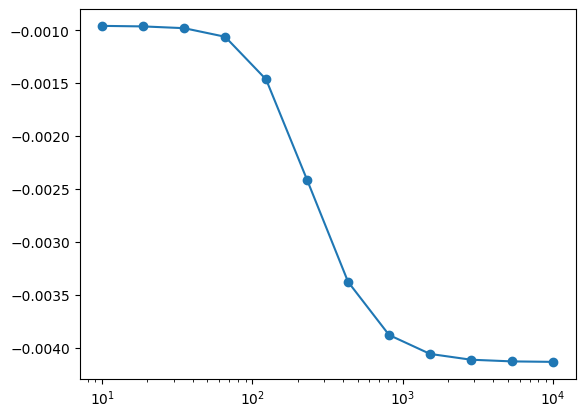

In [19]:
f = figure()
ax = f.add_subplot(1,1,1)
ax.semilogx( np.logspace(1, 4, 12), bscorrs.mean(2).mean(1), 'o-')

In [20]:
max_corrs = corr.copy()
max_corrs.sort()
idx = max_corrs[-5:]
inds = [int(np.where(corr == c)[0][0]) for c in idx]
print(inds)

[130736, 84751, 53339, 108582, 113147]


In [21]:
pred = np.dot(delPstim, wt)

print ("pred has shape: ", pred.shape)

pred has shape:  (69, 131065)


In [42]:
pred.shape

(69, 131065)

In [51]:
sim = []
for i in range(pred.shape[1]):
    rec = [zPresp[:,i]]
    pre = [pred[:,i]]
    cos = np.float16((cosine_similarity(rec,pre))[0][0])
    sim.append(cos)

[np.float16(0.4202), np.float16(0.2356), np.float16(0.3962), np.float16(-0.1327), np.float16(0.4478), np.float16(0.3293), np.float16(0.3542), np.float16(0.301), np.float16(0.3628), np.float16(0.5464), np.float16(0.5347), np.float16(0.1787), np.float16(0.465), np.float16(0.03038), np.float16(0.9272), np.float16(0.4844), np.float16(-0.09216), np.float16(0.519), np.float16(0.7803), np.float16(-0.0754), np.float16(0.08777), np.float16(0.2339), np.float16(0.46), np.float16(0.3252), np.float16(0.4675), np.float16(0.12146), np.float16(0.7837), np.float16(0.7515), np.float16(0.2566), np.float16(0.178), np.float16(0.10077), np.float16(0.09766), np.float16(0.05396), np.float16(0.04874), np.float16(-0.04578), np.float16(0.4336), np.float16(0.625), np.float16(0.6274), np.float16(-0.034), np.float16(0.3677), np.float16(0.5957), np.float16(0.3752), np.float16(0.3733), np.float16(0.1293), np.float16(0.2037), np.float16(0.649), np.float16(0.491), np.float16(0.3525), np.float16(0.2393), np.float16(0.3)

In [ ]:
sim = [float(k) for k in sim]


[0.420166015625, 0.235595703125, 0.396240234375, -0.1326904296875, 0.44775390625, 0.329345703125, 0.354248046875, 0.301025390625, 0.36279296875, 0.54638671875, 0.53466796875, 0.1787109375, 0.465087890625, 0.0303802490234375, 0.92724609375, 0.484375, -0.0921630859375, 0.51904296875, 0.7802734375, -0.07537841796875, 0.0877685546875, 0.23388671875, 0.4599609375, 0.3251953125, 0.467529296875, 0.1214599609375, 0.78369140625, 0.75146484375, 0.256591796875, 0.177978515625, 0.10076904296875, 0.09765625, 0.053955078125, 0.048736572265625, -0.0457763671875, 0.43359375, 0.625, 0.62744140625, -0.03399658203125, 0.36767578125, 0.595703125, 0.375244140625, 0.373291015625, 0.1292724609375, 0.2037353515625, 0.64892578125, 0.490966796875, 0.3525390625, 0.2392578125, 0.300048828125, 0.264404296875, 0.288818359375, 0.84326171875, 0.341064453125, 0.59228515625, 0.0767822265625, 0.52490234375, 0.87744140625, 0.5009765625, 0.5458984375, 0.62841796875, 0.61669921875, 0.048004150390625, 0.154052734375, 0.3410

In [23]:
np.where(corr > 0.75)

(array([ 42644,  44662,  53339,  55672,  55690,  71471,  78652,  83257,
         84751,  84775,  91767, 108559, 108582, 110985, 113147, 123989,
        123990, 130736, 130830]),)

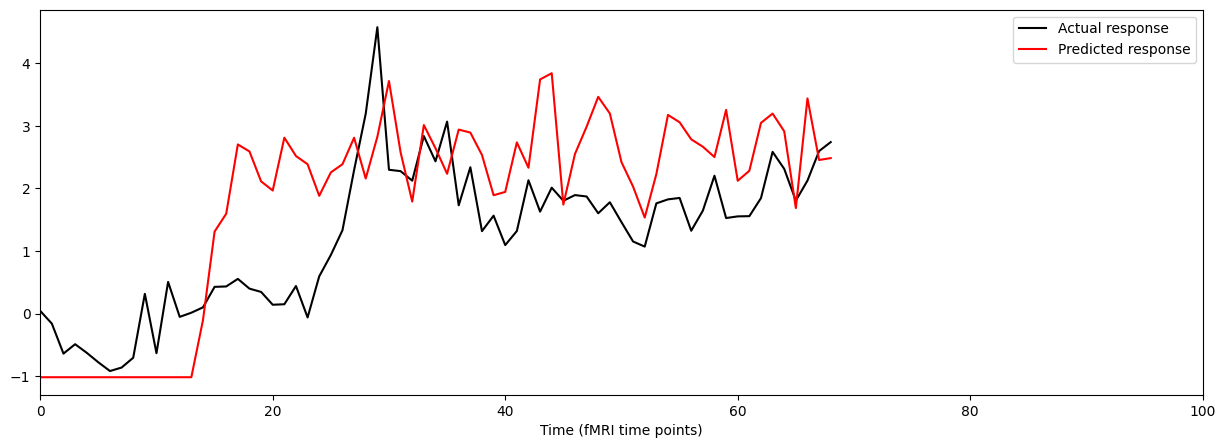

In [24]:
f = figure(figsize=(15,5))
ax = f.add_subplot(1,1,1)

selvox = 42644 # a decent voxel

realresp = ax.plot(zPresp[:,selvox], 'k')[0]
predresp = ax.plot(pred[:,selvox], 'r')[0]

ax.set_xlim(0, 100)
ax.set_xlabel("Time (fMRI time points)")

ax.legend((realresp, predresp), ("Actual response", "Predicted response"));

/tmp/ipykernel_2800218/1146598011.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
) missing from font(s) DejaVu Sans.sEnvironment/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 13 (
  func(*args, **kwargs)
) missing from font(s) DejaVu Sans.sEnvironment/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


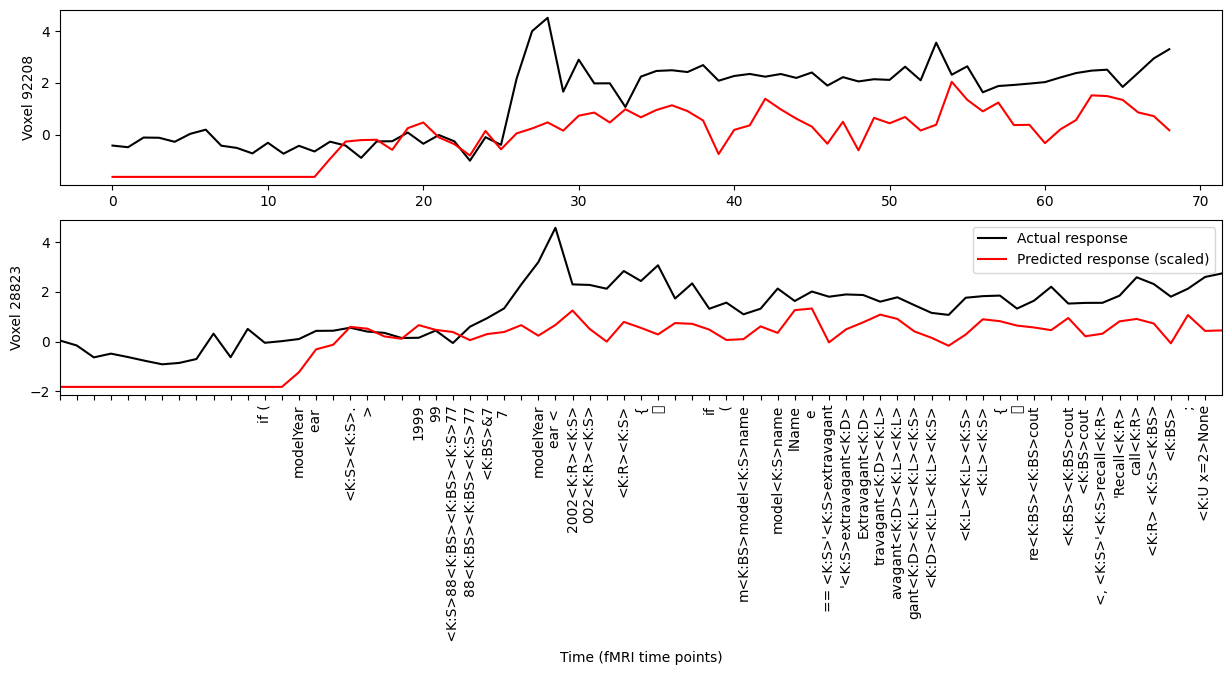

In [25]:
from npp import zscore

f = figure(figsize=(15,5))
ax = f.add_subplot(2,1,1)

# selvox = 65806 # a good voxel
# selvox = 34232 # a good voxel
# selvox = 130745 # a good voxel
# selvox = 38035 # a good voxel
# selvox = 51219
# selvox = 121999
# selvox = 516
# selvox = 128704
# selvox = 93399
# selvox = 93372
selvox = 27080  

realresp = ax.plot(zPresp[:,selvox], 'k')[0]
predresp = ax.plot(zscore(pred[:,selvox]), 'r')[0]
ax.set_ylabel("Voxel 92208")

ax = f.add_subplot(2,1,2)
selvox2 = 42644

realresp2 = ax.plot(zPresp[:,selvox2], 'k')[0]
predresp2 = ax.plot(zscore(pred[:,selvox2]), 'r')[0]

ax.set_xlim(0, len(Pkeys))
ax.set_xlabel(f"Time (fMRI time points)")
ax.set_ylabel("Voxel 28823")
ax.legend()


x_labels = list(Pkeys.values())

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90)

ax.legend((realresp, predresp), ("Actual response", "Predicted response (scaled)"));

In [26]:
Pkeys 

{677: '',
 678: '',
 679: '',
 680: '',
 681: '',
 682: '',
 683: '',
 684: '',
 685: '',
 686: '',
 687: '',
 688: '',
 689: 'if (',
 690: '',
 691: 'modelYear',
 692: 'ear ',
 693: '',
 694: '<K:S><K:S>.',
 695: '>',
 696: ' ',
 697: '',
 698: '1999',
 699: '99',
 700: ' <K:S>88<K:BS><K:BS><K:S>77',
 701: '88<K:BS><K:BS><K:S>77',
 702: '<K:BS>&7',
 703: '7 ',
 704: '',
 705: 'modelYear',
 706: 'ear < ',
 707: '2002<K:R><K:S>',
 708: '002<K:R><K:S>',
 709: '',
 710: '<K:R><K:S>',
 711: '{',
 712: '\r',
 713: '',
 714: '',
 715: 'if',
 716: ' (',
 717: 'm<K:BS>model<K:S>name',
 718: '',
 719: 'model<K:S>name',
 720: 'lName',
 721: 'e ',
 722: "== <K:S>'<K:S>extravagant",
 723: "'<K:S>extravagant<K:D>",
 724: 'Extravagant<K:D>',
 725: 'travagant<K:D><K:L>',
 726: 'avagant<K:D><K:L><K:L>',
 727: 'gant<K:D><K:L><K:L><K:S>',
 728: '<K:D><K:L><K:L><K:S>',
 729: '',
 730: '<K:L><K:L><K:S>',
 731: '<K:L><K:S>',
 732: '{',
 733: '\r',
 734: 're<K:BS><K:BS>cout',
 735: '',
 736: '<K:BS><K:BS>co

In [27]:
voxcorrs = np.zeros((zPresp.shape[1],)) # create zero-filled array to hold correlations
for vi in range(zPresp.shape[1]):
    voxcorrs[vi] = np.corrcoef(zPresp[:,vi], pred[:,vi])[0,1]
print (voxcorrs)

[ 0.34091731  0.20513535 -0.14199903 ...  0.35434345  0.41813172
  0.52354998]


In [28]:
np.where(corr > 0.75)

(array([ 42644,  44662,  53339,  55672,  55690,  71471,  78652,  83257,
         84751,  84775,  91767, 108559, 108582, 110985, 113147, 123989,
        123990, 130736, 130830]),)

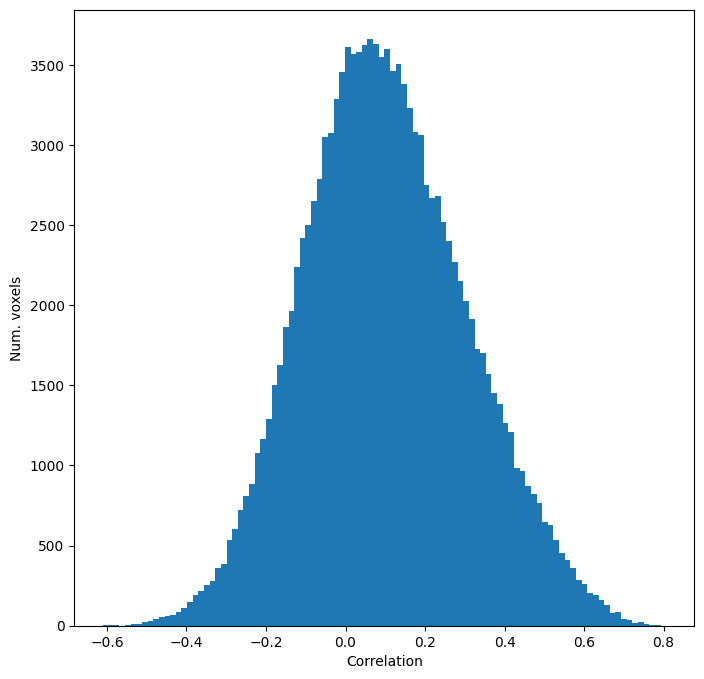

In [29]:
f = figure(figsize=(8,8))
ax = f.add_subplot(1,1,1)
ax.hist(corr, 100) # histogram correlations with 100 bins
ax.set_xlabel("Correlation")
ax.set_ylabel("Num. voxels");
plt.savefig(f"results/delayed_clean_embedding_layer_32.png",dpi=150)

In [30]:
# working backwards to save correlation values as voxels in MNI space
empty_schaefer[cortex] = voxcorrs
empty_mni[brain_idx] = empty_schaefer
result_brain = np.reshape(empty_mni, og_shape)

In [31]:
# Saving results
nifti_result = nib.Nifti1Image(result_brain, affine=atlas.affine, header=atlas.header)
nib.save(nifti_result, "layer_0_clean.nii.gz")

In [32]:
from collections import defaultdict

def nested_dict():
    return defaultdict(nested_dict)
test = nested_dict()

test['a']['b']['c']['d'] = 0

In [33]:
test

defaultdict(<function __main__.nested_dict()>,
            {'a': defaultdict(<function __main__.nested_dict()>,
                         {'b': defaultdict(<function __main__.nested_dict()>,
                                      {'c': defaultdict(<function __main__.nested_dict()>,
                                                   {'d': 0})})})})

In [34]:
import json
data = json.loads(json.dumps(test))
